# Three Steps MultiFidelity Neural Network

In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.callbacks import ModelCheckpoint
# import warnings
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from keras.models import save_model
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions import getModel, kCrossVal, transfBestparam, import_data
from time import perf_counter
import pandas
import pickle
import os

seed = 7
np.random.seed(seed)

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Data preparation

In [2]:
Discretizations= np.loadtxt(
    "../DATA/Discretizations.txt"
).astype(
    int
)

diffusion= np.loadtxt(
    "../DATA/diffusion.txt"
).astype(
    int
)

In [3]:
#file_path_LF = "../DATA/reaction_diffusion_LF_28_d1.mat"
#(reaction_LF_test, U_LF_test) = import_data(file_path_LF)
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

OSError: Can't read data (memory allocation failed for chunk)

In [ ]:
# NORMALIZATION

reaction_max = np.max(reaction_HF_test)
reaction_min = np.min(reaction_HF_test)

#reaction_LF_test = (reaction_LF_test - reaction_min) / (
#    reaction_max - reaction_min
#)
reaction_HF_test = (reaction_HF_test - reaction_min) / (
    reaction_max - reaction_min
)

In [ ]:
# Output
# We consider the central value of U
#U_LF_test = U_LF_test[
#    :,
#    - 1,
#    12,12
#]

U_HF_test = U_HF_test[:, -1, 44,44]

U_h_max_test = np.max(U_HF_test)
U_h_min_test = np.min(U_HF_test)
#U_t_max_test = np.max(U_LF_test)
#U_t_min_test = np.min(U_LF_test)

#U_LF_test = (U_LF_test - U_t_min_test) / (U_t_max_test - U_t_min_test)
U_HF_test = (U_HF_test - U_h_min_test) / (U_h_max_test - U_h_min_test)

#permutation = np.random.permutation(len(reaction_LF_test))
#Nlf = 20
#reaction_LF = reaction_LF_test[permutation][0:Nlf]
#U_LF = U_LF_test[permutation][0:Nlf]

permutation = np.random.permutation(len(reaction_HF_test))
n_HF = 15
reaction_HF = reaction_HF_test[permutation][0:n_HF]
U_HF = U_HF_test[permutation][0:n_HF]


In [ ]:
NepoLF = 5000  # number of epochs for first NN: NN_LF
NepoLin = 1500
NepoHF = 3000  # number of epochs for second NN: NN_HF 
Nlf=30

U_LF_list = []
U_Lin_list = []
U_HF_list = []
#HF_data = [10]
#HF_data_str = [str(num) for num in HF_data]
r2_HF_df = pandas.DataFrame(columns=['Discretization','Diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','Diffusion','R2'])  # dataframe which stores LF R^2
r2_Lin_df = pandas.DataFrame(columns=['Discretization','Diffusion','R2'])
mse_HF_df = pandas.DataFrame(columns=['Discretization','Diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','Diffusion','MSE'])  # dataframe which stores LF MSE
mse_Lin_df = pandas.DataFrame(columns=['Discretization','Diffusion','MSE'])


## Neural Network
Cycle on the Discretization and the value of the diffusion

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 2s 5ms/step

LF Model:
Test MSE: 0.03044107479818932
R^2: 0.7558288819987118
2/2 [==============================] - 0s 3ms/step
Elapsed time:  22.756435599999975
2/2 [==============================] - 0s 2ms/step

Lin Model:
Test MSE: 0.11979829934455961
R^2: -0.058300203780274895

HF Model:
Test MSE: 0.11856143344114513
R^2: -0.04737370945778374
2/2 [==============================] - 0s 3ms/step


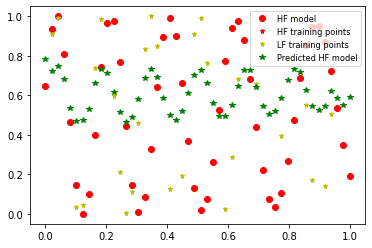

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.03670380237507451
R^2: 0.7049807763255015
2/2 [==============================] - 0s 3ms/step
Elapsed time:  22.5819616
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.13083193567448106
R^2: -0.15577153384322218

HF Model:
Test MSE: 0.12157530186038279
R^2: -0.07399827407762372
2/2 [==============================] - 0s 5ms/step


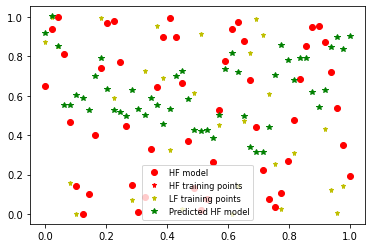

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.08323205943299486
R^2: 0.34757694652123294
2/2 [==============================] - 0s 3ms/step
Elapsed time:  23.196690400000023
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.11239184121659263
R^2: 0.007128572663148702

HF Model:
Test MSE: 0.11205768934711008
R^2: 0.010080475933076039
2/2 [==============================] - 0s 4ms/step


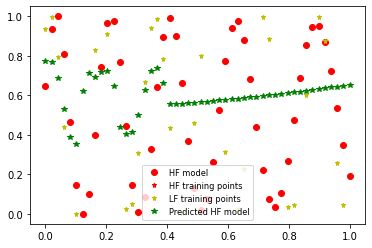

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.11688314764597267
R^2: 0.03794663961980871
2/2 [==============================] - 0s 4ms/step
Elapsed time:  26.270463300000074
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.11328070476991371
R^2: -0.0007236630093043761

HF Model:
Test MSE: 0.1137239312953511
R^2: -0.004639133635828907
2/2 [==============================] - 0s 4ms/step


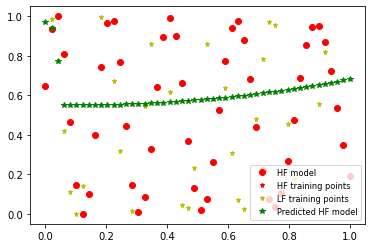

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.12661476256679202
R^2: -0.015921767527124375
2/2 [==============================] - 0s 3ms/step
Elapsed time:  22.624352600000066
2/2 [==============================] - 0s 4ms/step

Lin Model:
Test MSE: 0.11992557710793736
R^2: -0.059424577695900815

HF Model:
Test MSE: 0.11961446013738664
R^2: -0.056676165112961474
2/2 [==============================] - 0s 4ms/step


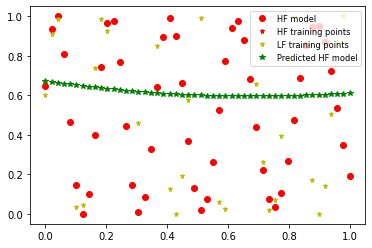

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.03003323756711986
R^2: 0.7348233279252022
2/2 [==============================] - 0s 3ms/step
Elapsed time:  22.621430099999998
2/2 [==============================] - 0s 2ms/step

Lin Model:
Test MSE: 0.0321880462991725
R^2: 0.7156502542684038

HF Model:
Test MSE: 0.032357334115166336
R^2: 0.7141547628370228
2/2 [==============================] - 0s 3ms/step


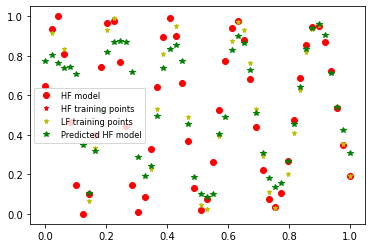

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.0004267933621755287
R^2: 0.9963700848977989
2/2 [==============================] - 0s 3ms/step
Elapsed time:  22.098676100000034
2/2 [==============================] - 0s 4ms/step

Lin Model:
Test MSE: 0.0728375058535625
R^2: 0.3565522406460375

HF Model:
Test MSE: 0.058227811568399124
R^2: 0.4856145272039315
2/2 [==============================] - 0s 5ms/step


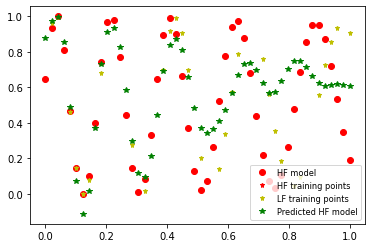

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.0017982809293712607
R^2: 0.9847920531994598
2/2 [==============================] - 0s 3ms/step
Elapsed time:  21.653312899999946
2/2 [==============================] - 0s 4ms/step

Lin Model:
Test MSE: 0.07981887438926945
R^2: 0.2948787128545146

HF Model:
Test MSE: 0.08783267082249957
R^2: 0.22408469954428967
2/2 [==============================] - 0s 4ms/step


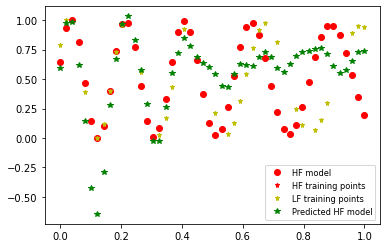

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.011062889520716497
R^2: 0.911200061356744
2/2 [==============================] - 0s 3ms/step
Elapsed time:  21.259266300000036
2/2 [==============================] - 0s 4ms/step

Lin Model:
Test MSE: 0.11847903520944641
R^2: -0.04664580208451574

HF Model:
Test MSE: 0.11795884755205636
R^2: -0.042050455515892926
2/2 [==============================] - 0s 3ms/step


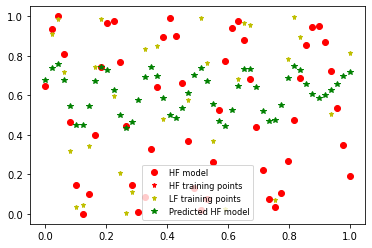

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.003507350102292379
R^2: 0.9691693030473909
2/2 [==============================] - 0s 3ms/step
Elapsed time:  21.328841700000112
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.02948047145927974
R^2: 0.7395690162248436

HF Model:
Test MSE: 0.029026199137951143
R^2: 0.7435820655992013
2/2 [==============================] - 0s 3ms/step


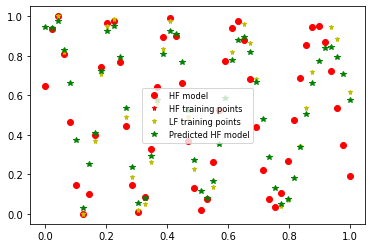

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.0041315932112678255
R^2: 0.9649235394216467
2/2 [==============================] - 0s 3ms/step
Elapsed time:  21.379146499999933
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.017951970619148633
R^2: 0.8414119877456734

HF Model:
Test MSE: 0.01761601617913195
R^2: 0.8443798149542046
2/2 [==============================] - 0s 3ms/step


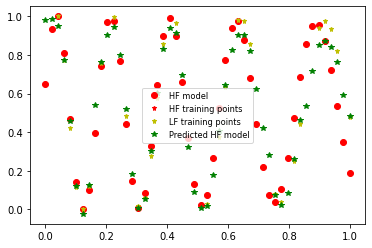

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.0006136775188408974
R^2: 0.9946984768271453
2/2 [==============================] - 0s 3ms/step
Elapsed time:  22.52404750000005
2/2 [==============================] - 0s 4ms/step

Lin Model:
Test MSE: 0.014838187817653453
R^2: 0.8689191977092472

HF Model:
Test MSE: 0.014958869513032363
R^2: 0.8678530935699496
2/2 [==============================] - 0s 4ms/step


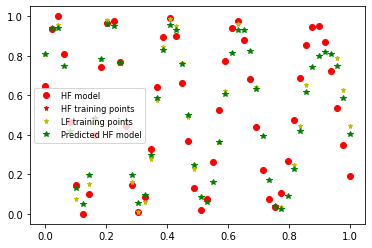

        10       28       46
0 -0.00464  0.22408  0.86785
        10       28       46
0  0.11372  0.08783  0.01496


In [ ]:
#checkpoint = ModelCheckpoint("best_model_3NN.h5", monitor="val_loss", save_best_only=True)


for m in range(len(Discretizations)):
    for d in range(len(diffusion)):    # Loop over the range of the number of basis functions
        file_path_LF = "../DATA/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
        (reaction_LF_test, U_LF_test) = import_data(file_path_LF)
        
        reaction_max = np.max(reaction_LF_test)
        reaction_min = np.min(reaction_LF_test)
        reaction_LF_test = (reaction_LF_test - reaction_min) / (
            reaction_max - reaction_min
        )
        
        permutation = np.random.permutation(len(reaction_LF_test))
        reaction_LF = reaction_LF_test[permutation][0:Nlf]
        U_LF_test = U_LF_test[
        :,
        - 1,
        int(4*(Discretizations[m]-1)/9),
        int(4*(Discretizations[m]-1)/9)
        ]
        U_t_max_test = np.max(U_LF_test)
        U_t_min_test = np.min(U_LF_test)
        
        U_LF_test = (U_LF_test - U_t_min_test) / (U_t_max_test - U_t_min_test)
       

        U_train_LF = U_LF_test[permutation][0:Nlf]


        print(
        f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
        )
        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )

        test_mse_HF_list = []
        test_mse_LF_list = []
        test_mse_Lin_list = []

        r2_HF_list = []
        r2_LF_list = []
        r2_Lin_list = []
 

       ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        }

        modelLF = getModel(bestLF_params, "LF")

        histLF = modelLF.fit(
            reaction_LF, U_train_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
        )
        print("LF NN done")

        ULF = modelLF.predict(reaction_LF_test)
        U_LF_list.append(ULF)
        print("\nLF Model:")

        test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
        test_mse_LF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
            np.square(U_LF_test - np.mean(U_LF_test))
        )
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")

        start = perf_counter()
        ##########################    SECOND NN: NN_Lin    ##########################
        reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
        reaction_test_in = np.vstack(
            (reaction_HF_test[:, 0], reaction_test_help)
        ).transpose()  # <- TEST INPUT for the second NN: NN_Lin

        reaction_train_help = modelLF.predict(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        reaction_lin = np.vstack(
            (reaction_HF[:, 0], reaction_train_help)
        ).transpose()  # <- TRAINING INPUT for the second NN: NN_Lin

        bestLin_params = {
            "lr": 0.001,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
            "l2weight": 0.01,
        }
        modelLin = getModel(bestLin_params, "Hflin")
        histLin = modelLin.fit(
            reaction_lin,
            U_HF,
            validation_data=(reaction_test_in, U_HF_test),
            epochs=NepoLin,
            batch_size=n_HF,
            verbose=0,
            validation_freq=50,
        )

        ULin = modelLin.predict(
            np.vstack((reaction_HF_test[:, 0], reaction_test_help)).transpose()
        )

        ##########################    THIRD NN: NN_HF    ##########################
        # Input for training NN_HF
        reaction_help1 = modelLin.predict(reaction_lin)[:, 0]
        reaction_final = np.vstack(
            (reaction_HF[:, 0], reaction_train_help, reaction_help1)
        ).transpose()

        # Input for testing NN_HF
        reaction_test_help1 = modelLin.predict(reaction_test_in)[:, 0]
        reaction_test_final = np.vstack(
            (reaction_HF_test[:, 0], reaction_test_help, reaction_test_help1)
        ).transpose()

        name = "3step"
        MAX_EVAL = 15

        K.clear_session()
        # best paramters obtained by HPO:
        
        best_params={'kernel_init': 'glorot_uniform', 'l2weight': 0.0001933368067753076, 'lr': 0.004404993622688278, 'nodes': 10.0, 'opt': 'Adam'}
        #best_params = {
        #    "kernel_init": "glorot_uniform",
        #    "l2weight": 0.0001738393292451542,
        #    "lr": 0.0003670853655509693,
        #    "nodes": 48.0,
        #    "opt": "Adam",
        #}
        # best_params = {'kernel_init': 'glorot_uniform', 'l2weight': 0.00015338174139229794, 'lr': 0.010752960934369659, 'nodes': 28.0, 'opt': 'Adam'}
        finalModel = getModel(
            best_params, name
        )  # final model chosen according to the best paramters
        hist = finalModel.fit(
            reaction_final,
            U_HF,
            validation_data=(reaction_test_final, U_HF_test),
            epochs=NepoHF,
            batch_size=n_HF,
            validation_freq=50,
            verbose=0,
        )

        UHF = finalModel.predict(reaction_test_final)
        U_HF_list.append(UHF)

        stop = perf_counter()
        elapsed = stop - start
        print("Elapsed time: ", elapsed)

        ULin = modelLin.predict(
            np.vstack((reaction_HF_test[:, 0], reaction_test_help)).transpose()
        )
        U_Lin_list.append(ULin)
        print("\nLin Model:")

        test_mse = np.mean(np.square(U_HF_test - ULin[:, 0]))
        test_mse_Lin_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r2_Lin = 1 - np.sum(np.square(U_HF_test - ULin[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_Lin_list.append(r2_Lin)
        print(f"R^2: {r2_Lin}")

        print("\nHF Model:")
        test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
        test_mse_HF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")
        r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_HF_list.append(r2_HF)
        print(f"R^2: {r2_HF}")

        plt.figure()
        plt.plot(
        reaction_test_in[:, 0], U_HF_test, "ro", linewidth=1.5, label="HF model"
        )
        plt.plot(
        reaction_final[:, 0],
        U_HF,
        "r*",
        markersize=5,
        label="HF training points",
        )
        plt.plot(
        reaction_LF,
        U_train_LF,
        "y*",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_test_in[:, 0],
        finalModel.predict(reaction_test_final),
        "g*",
        linewidth=3,
        label="Predicted HF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()
    
        
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
        r2_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
        r2_HF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_Lin_list[-1]}
        r2_Lin_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': test_mse_LF_list[-1]}
        mse_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': test_mse_HF_list[-1]}
        mse_HF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': test_mse_Lin_list[-1]}
        mse_Lin_df.append(new, ignore_index=True)
        
        if r2_HF_list[-1]<max(r2_HF_list[:-1]):
            save_model(finalModel,"finalModel.h5")

print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

# Da eliminare seguente cella

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.20250048791397318
R^2: -0.6242780801124093
2/2 [==============================] - 0s 4ms/step
Elapsed time:  44.022466699999995
2/2 [==============================] - 0s 5ms/step

Lin Model:
Test MSE: 0.11961619588101458
R^2: -0.056691498701544996

HF Model:
Test MSE: 0.1397912768563471
R^2: -0.23491850546453863
2/2 [==============================] - 0s 5ms/step


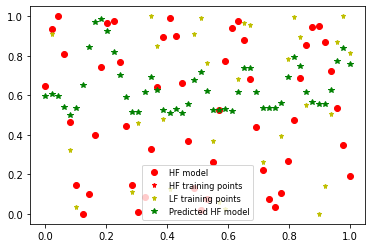

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 0.01568689674967331
R^2: 0.8739112625537278
2/2 [==============================] - 0s 2ms/step
Elapsed time:  43.04899139999998
2/2 [==============================] - 0s 4ms/step

Lin Model:
Test MSE: 0.12355374815801648
R^2: -0.09147590215255974

HF Model:
Test MSE: 0.1367641830149591
R^2: -0.2081771072416061
2/2 [==============================] - 0s 3ms/step


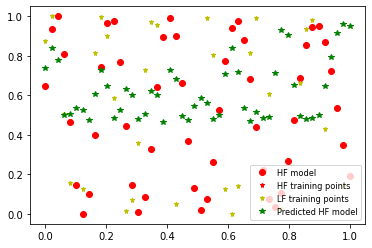

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 0.1362987625142258
R^2: -0.06839186042844747
2/2 [==============================] - 0s 3ms/step
Elapsed time:  42.60411720000002
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.11987519431530677
R^2: -0.05897949525316415

HF Model:
Test MSE: 0.12738154844370045
R^2: -0.12529075465491712
2/2 [==============================] - 0s 4ms/step


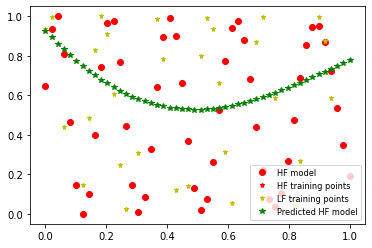

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.12229218384887329
R^2: -0.006574590003304959
2/2 [==============================] - 0s 3ms/step
Elapsed time:  42.78935619999993
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.11996347415540687
R^2: -0.059759360854585664

HF Model:
Test MSE: 0.12304696133544506
R^2: -0.08699893878550968
2/2 [==============================] - 0s 4ms/step


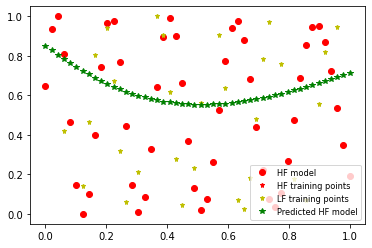

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.009107010592107907
R^2: 0.9269278707311727
2/2 [==============================] - 0s 4ms/step
Elapsed time:  44.42500679999989
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.12223743102065064
R^2: -0.07984753428477331

HF Model:
Test MSE: 0.14352048052968366
R^2: -0.267862353824849
2/2 [==============================] - 0s 4ms/step


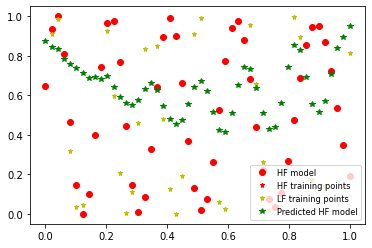

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.11635104047634101
R^2: -0.027314542330076685
2/2 [==============================] - 0s 3ms/step
Elapsed time:  44.240247599999975
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.11991532772343712
R^2: -0.059334034459773255

HF Model:
Test MSE: 0.12118522844001825
R^2: -0.07055235888083344
2/2 [==============================] - 0s 3ms/step


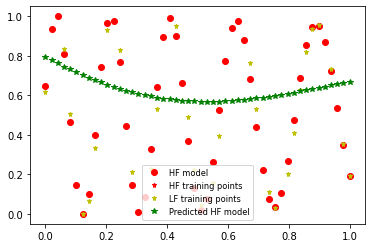

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 8.835141808250738e-05
R^2: 0.9992485634144734
2/2 [==============================] - 0s 3ms/step
Elapsed time:  44.14398950000009
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.07335009633000442
R^2: 0.352024007702479

HF Model:
Test MSE: 0.06226304226826737
R^2: 0.4499672309122841
2/2 [==============================] - 0s 2ms/step


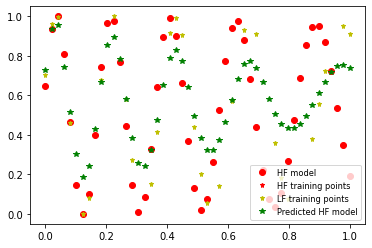

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.11877937917162366
R^2: -0.0045096124523851255
2/2 [==============================] - 0s 3ms/step
Elapsed time:  43.20783849999998
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.11993082433534742
R^2: -0.05947093179164109

HF Model:
Test MSE: 0.12393177073928024
R^2: -0.094815360032795
2/2 [==============================] - 0s 3ms/step


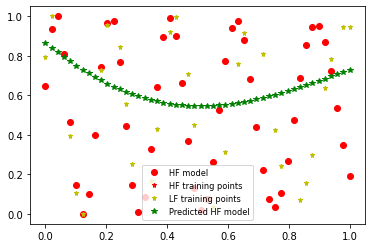

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.12504468553691245
R^2: -0.0037124914381234664
2/2 [==============================] - 0s 3ms/step
Elapsed time:  42.58246609999992
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.11994129414364844
R^2: -0.059563422255354936

HF Model:
Test MSE: 0.1196498589804456
R^2: -0.05698887909160599
2/2 [==============================] - 0s 3ms/step


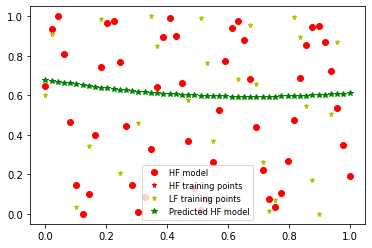

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 0.048415677914242804
R^2: 0.5744111508704135
2/2 [==============================] - 0s 3ms/step
Elapsed time:  43.97304669999994
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.053824000713222846
R^2: 0.5245178668251254

HF Model:
Test MSE: 0.053492651998716216
R^2: 0.527445006976557
2/2 [==============================] - 0s 3ms/step


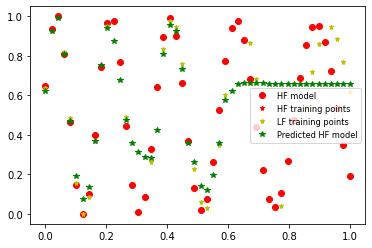

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.0003902414670705942
R^2: 0.996686922275308
2/2 [==============================] - 0s 4ms/step
Elapsed time:  43.969315399999914
2/2 [==============================] - 0s 4ms/step

Lin Model:
Test MSE: 0.015663578560779764
R^2: 0.8616276819162177

HF Model:
Test MSE: 0.015338005862325593
R^2: 0.8645037966440934
2/2 [==============================] - 0s 2ms/step


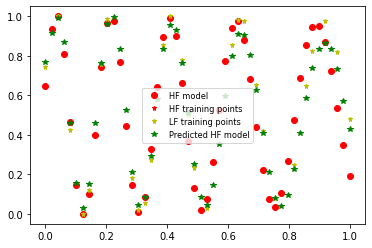

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 0.0180100446962299
R^2: 0.8444123071649206
2/2 [==============================] - 0s 3ms/step
Elapsed time:  43.67928659999984
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.026712896304490287
R^2: 0.7640178219784782

HF Model:
Test MSE: 0.02898109086293204
R^2: 0.7439805528640964
2/2 [==============================] - 0s 3ms/step


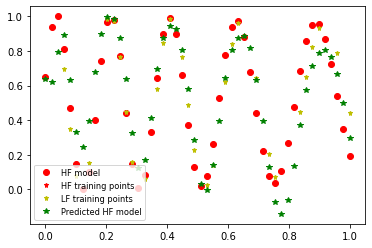

      10       28       46
0 -0.087 -0.09482  0.74398
        10       28       46
0  0.12305  0.12393  0.02898


In [ ]:
checkpoint = ModelCheckpoint("best_model_3NN.h5", monitor="val_loss", save_best_only=True)

for m in range(len(Discretizations)):
    for d in range(len(diffusion)):    # Loop over the range of the number of basis functions
        file_path_LF = "../DATA/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
        (reaction_LF_test, U_LF_test) = import_data(file_path_LF)
        
        reaction_max = np.max(reaction_LF_test)
        reaction_min = np.min(reaction_LF_test)
        reaction_LF_test = (reaction_LF_test - reaction_min) / (
            reaction_max - reaction_min
        )
        
        permutation = np.random.permutation(len(reaction_LF_test))
        reaction_LF = reaction_LF_test[permutation][0:Nlf]
        U_LF_test = U_LF_test[
        :,
        - 1,
        int(4*(Discretizations[m]-1)/9),
        int(4*(Discretizations[m]-1)/9)
        ]
        U_t_max_test = np.max(U_LF_test)
        U_t_min_test = np.min(U_LF_test)
        
        U_LF_test = (U_LF_test - U_t_min_test) / (U_t_max_test - U_t_min_test)
       

        U_train_LF = U_LF_test[permutation][0:Nlf]


        print(
        f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
        )
        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )

        test_mse_HF_list = []
        test_mse_LF_list = []
        test_mse_Lin_list = []

        r2_HF_list = []
        r2_LF_list = []
        r2_Lin_list = []
 

       ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        }

        modelLF = getModel(bestLF_params, "LF")

        histLF = modelLF.fit(
            reaction_LF, U_train_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
        )
        print("LF NN done")

        ULF = modelLF.predict(reaction_LF_test)
        U_LF_list.append(ULF)
        print("\nLF Model:")

        test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
        test_mse_LF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
            np.square(U_LF_test - np.mean(U_LF_test))
        )
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")

        start = perf_counter()
        ##########################    SECOND NN: NN_Lin    ##########################
        reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
        reaction_test_in = np.vstack(
            (reaction_HF_test[:, 0], reaction_test_help)
        ).transpose()  # <- TEST INPUT for the second NN: NN_Lin

        reaction_train_help = modelLF.predict(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        reaction_lin = np.vstack(
            (reaction_HF[:, 0], reaction_train_help)
        ).transpose()  # <- TRAINING INPUT for the second NN: NN_Lin

        bestLin_params = {
            "lr": 0.001,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
            "l2weight": 0.01,
        }
        modelLin = getModel(bestLin_params, "Hflin")
        histLin = modelLin.fit(
            reaction_lin,
            U_HF,
            validation_data=(reaction_test_in, U_HF_test),
            epochs=NepoLin,
            batch_size=n_HF,
            verbose=0,
            validation_freq=50,
        )

        ULin = modelLin.predict(
            np.vstack((reaction_HF_test[:, 0], reaction_test_help)).transpose()
        )

        ##########################    THIRD NN: NN_HF    ##########################
        # Input for training NN_HF
        reaction_help1 = modelLin.predict(reaction_lin)[:, 0]
        reaction_final = np.vstack(
            (reaction_HF[:, 0], reaction_train_help, reaction_help1)
        ).transpose()

        # Input for testing NN_HF
        reaction_test_help1 = modelLin.predict(reaction_test_in)[:, 0]
        reaction_test_final = np.vstack(
            (reaction_HF_test[:, 0], reaction_test_help, reaction_test_help1)
        ).transpose()

        name = "3step"
        MAX_EVAL = 15

        K.clear_session()
        # best paramters obtained by HPO:
        best_params = {
            "kernel_init": "glorot_uniform",
            "l2weight": 0.0001738393292451542,
            "lr": 0.0003670853655509693,
            "nodes": 48.0,
            "opt": "Adam",
        }
        # best_params = {'kernel_init': 'glorot_uniform', 'l2weight': 0.00015338174139229794, 'lr': 0.010752960934369659, 'nodes': 28.0, 'opt': 'Adam'}
        finalModel = getModel(
            best_params, name
        )  # final model chosen according to the best paramters
        hist = finalModel.fit(
            reaction_final,
            U_HF,
            validation_data=(reaction_test_final, U_HF_test),
            epochs=NepoHF,
            batch_size=n_HF,
            validation_freq=50,
            verbose=0,
            callbacks=[checkpoint]
        )

        UHF = finalModel.predict(reaction_test_final)
        U_HF_list.append(UHF)

        stop = perf_counter()
        elapsed = stop - start
        print("Elapsed time: ", elapsed)

        ULin = modelLin.predict(
            np.vstack((reaction_HF_test[:, 0], reaction_test_help)).transpose()
        )
        U_Lin_list.append(ULin)
        print("\nLin Model:")

        test_mse = np.mean(np.square(U_HF_test - ULin[:, 0]))
        test_mse_Lin_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r2_Lin = 1 - np.sum(np.square(U_HF_test - ULin[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_Lin_list.append(r2_Lin)
        print(f"R^2: {r2_Lin}")

        print("\nHF Model:")
        test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
        test_mse_HF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")
        r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_HF_list.append(r2_HF)
        print(f"R^2: {r2_HF}")

        plt.figure()
        plt.plot(
        reaction_test_in[:, 0], U_HF_test, "ro", linewidth=1.5, label="HF model"
        )
        plt.plot(
        reaction_final[:, 0],
        U_HF,
        "r*",
        markersize=5,
        label="HF training points",
        )
        plt.plot(
        reaction_LF,
        U_train_LF,
        "y*",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_test_in[:, 0],
        finalModel.predict(reaction_test_final),
        "g*",
        linewidth=3,
        label="Predicted HF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()



        checkpoint = ModelCheckpoint("best_model.h5", monitor="val_loss", save_best_only=True)

        
        r2_LF_df[str(Discretizations[m])] = r2_LF_list
        r2_HF_df[str(Discretizations[m])] = r2_HF_list
        r2_Lin_df[str(Discretizations[m])] = r2_Lin_list
        mse_LF_df[str(Discretizations[m])] = test_mse_LF_list
        mse_HF_df[str(Discretizations[m])] = test_mse_HF_list
        mse_Lin_df[str(Discretizations[m])] = test_mse_Lin_list

print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

# Save the output

In [ ]:
#########################     SAVE the OUTPUT      ##########################
os.makedirs("Output_3NN_finale")

r2_HF_df.to_csv(
    "./Output_3NN_finale/r2_HF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_HF_df.to_csv(
    "./Output_3NN_finale/mse_HF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
r2_LF_df.to_csv(
    "./Output_3NN_finale/r2_LF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_LF_df.to_csv(
    "./Output_3NN_finale/mse_LF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
r2_Lin_df.to_csv(
    "./Output_3NN_finale/r2_Lin_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_Lin_df.to_csv(
    "./Output_3NN_finale/mse_Lin_lhs.txt", header=True, index=False, sep="\t", mode="a"
)

with open("estimated_UHF2.txt", "w") as file:
    for item in UHF[:, 0]:
        file.write(f"{UHF}\n")